In this notebook I check the simulation of a microstrip line against results from HFSS against theory of transmission lines, to be sure that I am setting up things correctly. Simulations are in both-ports.aedt. 
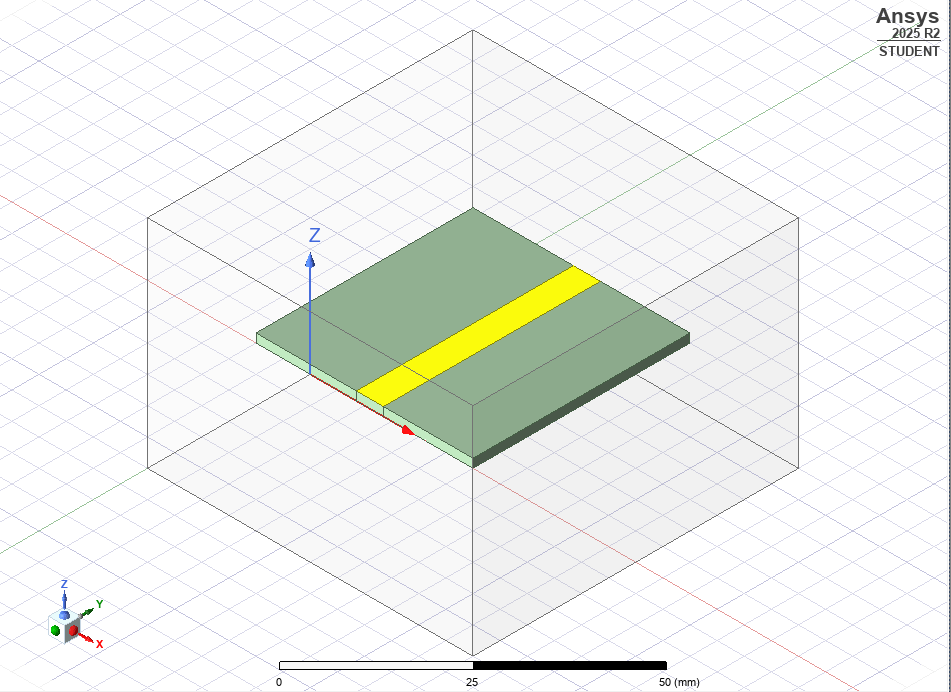

Conclusions: the amplitude of S11 is as expected, and changes with the width of the microstrip as one would expect. However, the exact frequencies are a bit off, almost seems like the electrical length is shorter in HFSS. Also, the simulation is set up between two ports, but strangely, the S parameter plot assumes a 50 Ohm load on port 2, while the Z parameter plot assumes it is open. Given that this uses lumped port, while the antenna uses wave port (https://innovationspace.ansys.com/courses/wp-content/uploads/sites/5/2021/07/HFSS_GS_2020R2_EN_LE6_Port_Basics.pdf), I decided it is not worth more time.

In [163]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import numpy as np


In [154]:
def microstrip_z0(eps_r, h, W):

    W = np.asarray(W)
    h = np.asarray(h)
    eps_r = np.asarray(eps_r)
    wh = W / h
    epsilon_eff = (eps_r + 1)/2 + (eps_r - 1)/2 * (1 / np.sqrt(1 + 12/wh))
    Z0 = np.zeros_like(wh, dtype=float)

    mask1 = wh <= 1
    Z0[mask1] = (60 / np.sqrt(epsilon_eff[mask1])) * np.log(
        8/wh[mask1] + wh[mask1]/4
    )
    mask2 = wh > 1
    Z0[mask2] = (120 * np.pi) / (
        np.sqrt(epsilon_eff[mask2]) *
        (wh[mask2] + 1.393 + 0.667 * np.log(wh[mask2] + 1.444))
    )

    return Z0

def get_eps_eff(eps_r, W, h):
    wh = W/h
    eps_eff = (eps_r + 1)/2 + (eps_r - 1)/2 * (1 / np.sqrt(1 + 12/wh))
    return eps_eff
    
def get_gamma(alpha, eps_eff, f):
    c = 3e8
    v = c/np.sqrt(eps_eff)
    
    beta = 2 * np.pi * f / v
    lambda_ = 2 * np.pi / beta
    gamma = alpha + 1j * beta
    return gamma
    
def z_in(l, gamma, z0, z_load=50):
    return z0 * (z_load + z0 * np.tanh(gamma * l)) / (z0 + z_load * np.tanh(gamma * l))

def reflection(z_in, z0=50):
    return np.abs((z_in - z0) / (z_in + z0))

In [164]:
def get_alpha(f, eps_eff, tan_delta=0.02):
    c = 3e8
    
    # dielectric loss
    alpha_d = (np.pi * f / c) * np.sqrt(eps_eff) * tan_delta
    
    # crude conductor loss (~ sqrt(f) scaling)
    alpha_c = 0.02 * np.sqrt(f / 1e9)  # tweakable
    
    return alpha_d + alpha_c


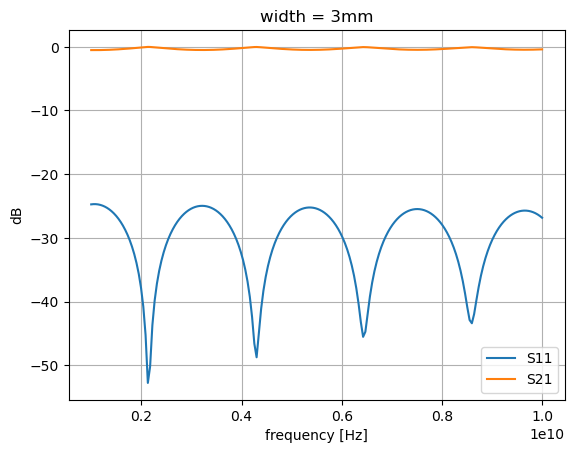

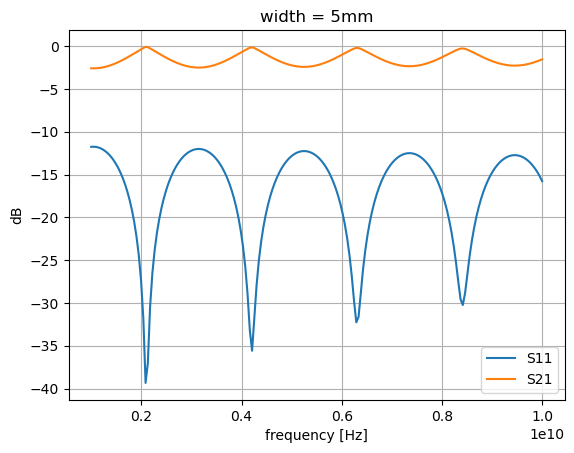

In [172]:

W_list = [3e-3, 5e-3]
for W in W_list:
    fig, ax = plt.subplots()
    
    h = 1.6e-3
    eps_r = 4
    eps_eff = get_eps_eff(eps_r=eps_r, W=W, h=h)
    
    z_load = 50
    f_range = np.linspace(1e9, 10e9, 200)
    
    alpha = get_alpha(f_range, eps_eff=eps_eff)
    gamma = get_gamma(alpha=alpha, eps_eff=eps_eff, f=f_range)
    z0 = microstrip_z0(eps_r=eps_r, h=h, W=W)
    s11 = reflection(z_in(l=40e-3, gamma=gamma, z0=z0, z_load=z_load))
    ax.plot(f_range, 20 * np.log10(s11), label="S11")
    ax.plot(f_range, 20 * np.log10(1 - s11), label="S21")
    ax.set_xlabel("frequency [Hz]")
    ax.set_ylabel("dB")
    ax.set_title(f"width = {W/1e-3:.0f}mm")
    ax.legend()
    ax.grid()

width: 3mm 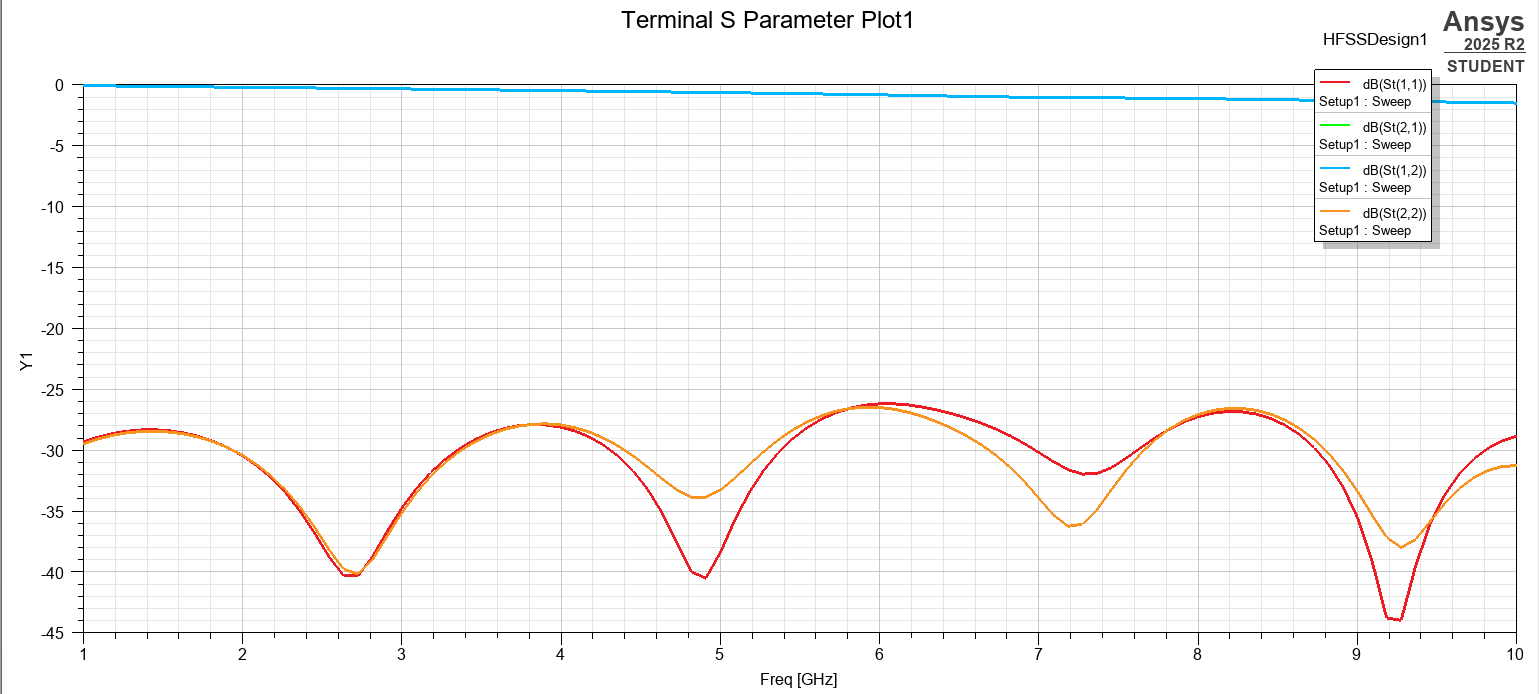
width: 5mm 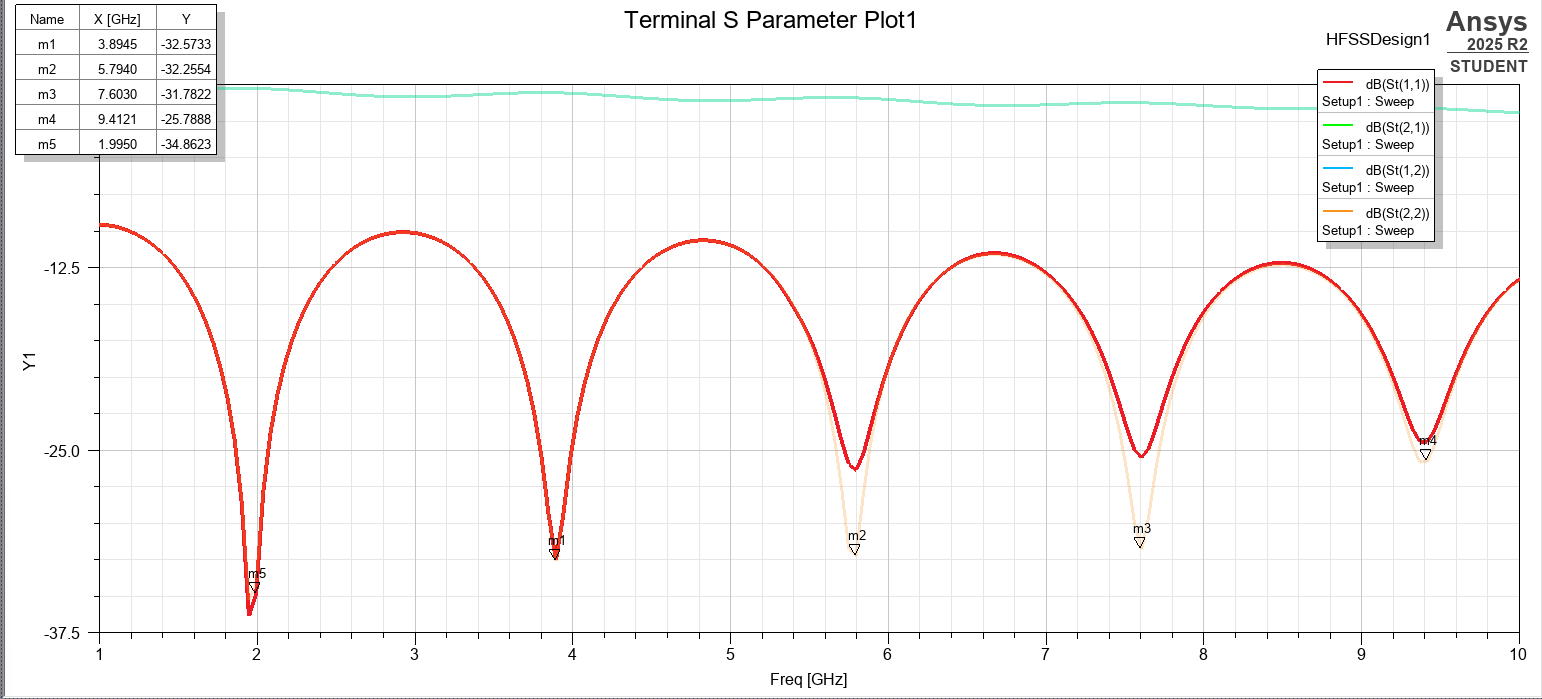

Text(0.5, 1.0, 'z parameters')

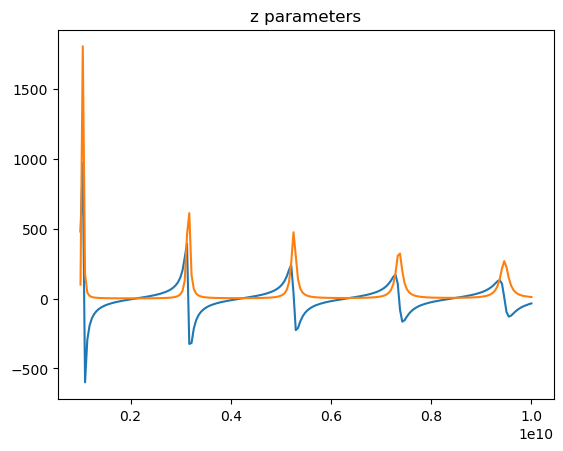

In [175]:
W = 5e-3
h = 1.6e-3
eps_r = 4
eps_eff = get_eps_eff(eps_r=eps_r, W=W, h=h)

z_load = 50
f_range = np.linspace(1e9, 10e9, 200)

alpha = get_alpha(f_range, eps_eff=eps_eff)
gamma = get_gamma(alpha=alpha, eps_eff=eps_eff, f=f_range)

fig, ax = plt.subplots()
ax.plot(f_range, np.imag(z_in(l=40e-3, gamma=gamma, z0=z0, z_load=0)))
ax.plot(f_range, np.real(z_in(l=40e-3, gamma=gamma, z0=z0, z_load=0)))
ax.set_title("z parameters")


width: 5mm
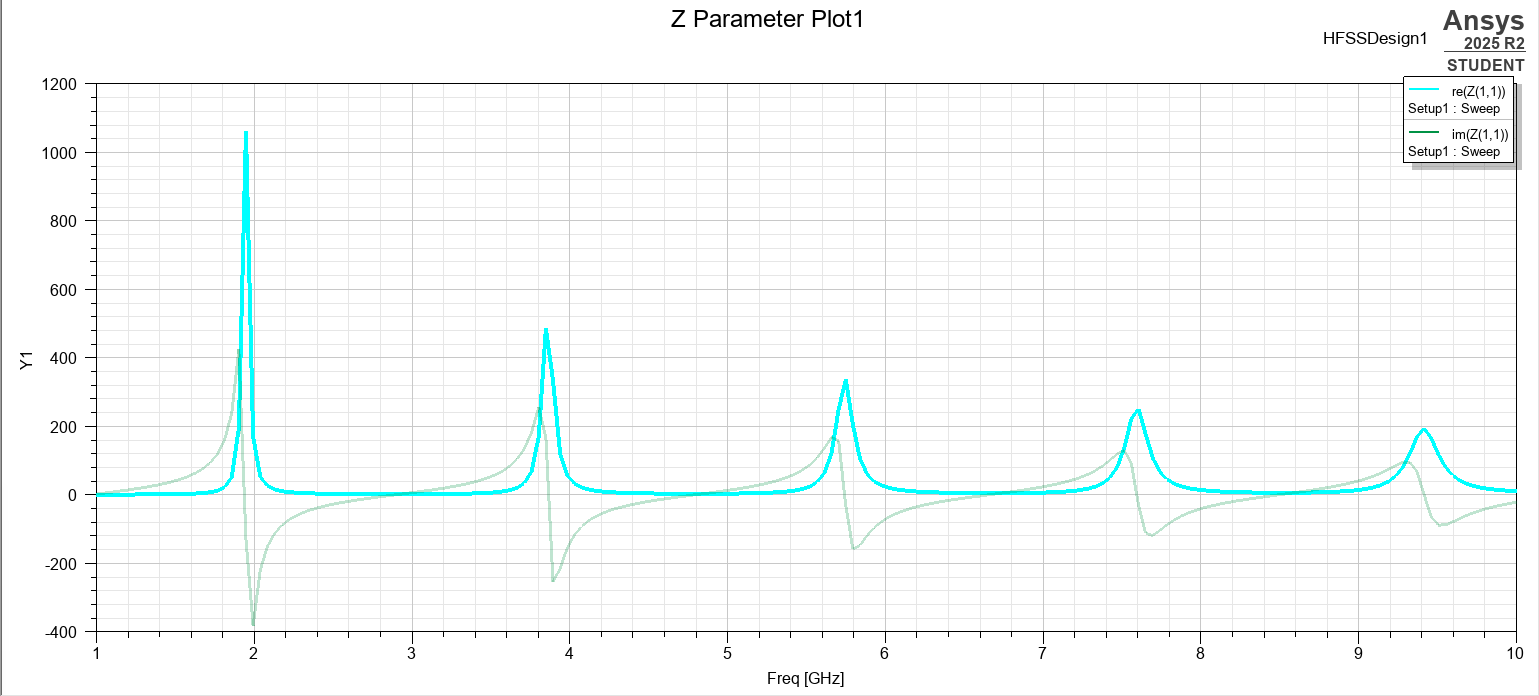